In [1]:
import numpy as np
import matplotlib.pyplot as plt

from config import PipelineConfig
from signal_types import SignalBlock
from main_pipeline import MicroDopplerPipeline

In [2]:
cfg = PipelineConfig(
    n_subcarriers=128,
    cp_len=16,
    n_symbols_per_frame=128,
    sample_rate=1e6,
    carrier_freq=3.5e9,
)

cfg.stft.window = "hann"
cfg.stft.nperseg = 32
cfg.stft.noverlap = 24
cfg.stft.nfft = 64

pipe = MicroDopplerPipeline(cfg)

In [3]:
F = 8    # n_frames
M = cfg.n_symbols_per_frame
N = cfg.n_subcarriers

grid = np.zeros((F, M, N), dtype=np.complex128)

pilot_idx = np.arange(0, N, cfg.pilot.pilot_spacing)
msync = cfg.pilot.msync

# Secuencia ZC simple igual a la del pipeline
def zc_seq(length, root=1):
    n = np.arange(length)
    if length % 2 == 0:
        return np.exp(-1j * np.pi * root * (n ** 2) / length)
    else:
        return np.exp(-1j * np.pi * root * n * (n + 1) / length)

zc = zc_seq(N, cfg.pilot.zc_root)

# Parámetro Doppler sintético:
# fase lineal entre símbolos
fd_norm = 0.06  # frecuencia Doppler "normalizada"
for f in range(F):
    phase_traj = np.exp(1j * np.cumsum(np.random.randn(M) * 0.1))
    for m in range(M):
        # phase = np.exp(1j * 2 * np.pi * fd_norm * m)
        # phase = np.exp(1j * 2*np.pi * f * m)
        phase = np.exp(1j * 2*np.pi * (0.01*m + 0.001*m**2))
        # phase = phase_traj[m]
        if m == msync:
            grid[f, m, :] = zc * phase
        else:
            grid[f, m, pilot_idx] = zc[pilot_idx] * phase

# ruido
noise = 0.05 * (np.random.randn(*grid.shape) + 1j*np.random.randn(*grid.shape))
grid_noisy = grid + noise

In [4]:
block = SignalBlock(source_type="synthetic_grid", data=grid_noisy, metadata={})
result = pipe.run(block)

spec = result["spectrogram"]
print(spec.spec.shape)

(256, 64, 12)


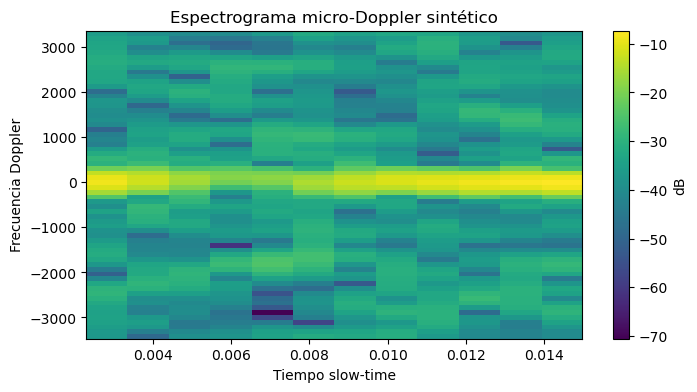

In [5]:
S = spec.spec[0]  # primera serie
plt.figure(figsize=(8, 4))
plt.imshow(
    10*np.log10(S + 1e-12),
    aspect="auto",
    origin="lower",
    extent=[spec.times[0], spec.times[-1], spec.freqs[0], spec.freqs[-1]]
)
plt.xlabel("Tiempo slow-time")
plt.ylabel("Frecuencia Doppler")
plt.title("Espectrograma micro-Doppler sintético")
plt.colorbar(label="dB")
plt.show()

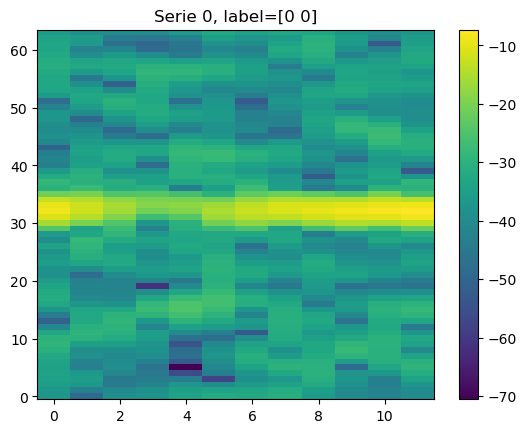

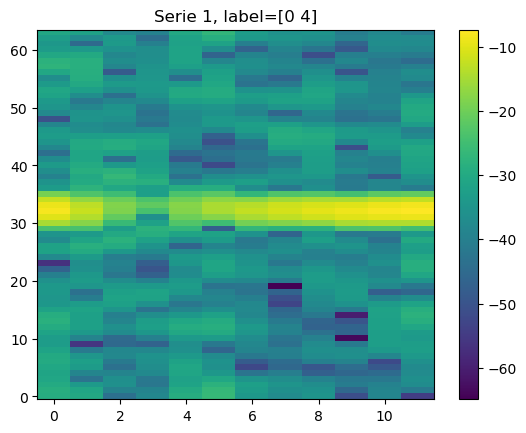

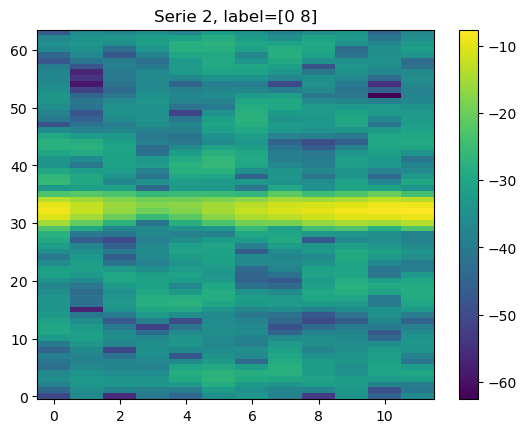

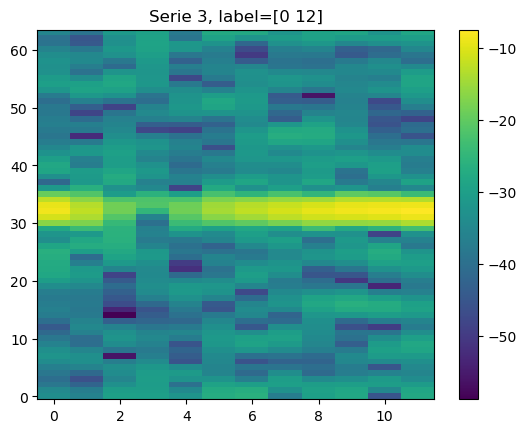

In [6]:
for i in range(4):
    plt.figure()
    plt.title(f"Serie {i}, label={result['slowtime'].labels[i]}")
    plt.imshow(
        10*np.log10(spec.spec[i] + 1e-12),
        aspect="auto",
        origin="lower"
    )
    plt.colorbar()
    plt.show()